<a href="https://colab.research.google.com/github/Rouba-Os/AI-Course/blob/main/Assignment15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get install -y git
!git config --global user.email "rouba.osko@students.williscollege.com"
!git config --global user.name "Rouba-Os"

print("Git configured successfully")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Git configured successfully


In [2]:
!git clone https://github.com/Rouba-Os/AI-Course.git
%cd AI-Course
!ls

Cloning into 'AI-Course'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 81 (delta 42), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 1.15 MiB | 5.02 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/AI-Course
AICourse.ipynb	    Assignment3.ipynb  Assignment8.ipynb
Assignment11.ipynb  Assignment4.ipynb  Assignment9.ipynb
Assignment13.ipynb  Assignment5.ipynb  git_github_exercise.ipynb
Assignment14.ipynb  Assignment6.ipynb  README.md
assignment2.ipynb   Assignment7.ipynb


In [3]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [4]:
!pip install fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 27.5 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate
import shap

In [7]:
# Task 1
# Load dataset
data = pd.read_csv('bank-loan1.csv')

print('Data first few rows', data.head())
print('\nData Info\n', data.info())

Data first few rows    age  ed  employ  address  income  debtinc   creddebt   othdebt  default
0   41   3      17       12     176      9.3  11.359392  5.008608      1.0
1   27   1      10        6      31     17.3   1.362202  4.000798      0.0
2   40   1      15       14      55      5.5   0.856075  2.168925      0.0
3   41   1      15       14     120      2.9   2.658720  0.821280      0.0
4   24   2       2        0      28     17.3   1.787436  3.056564      1.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float

In [8]:
# Task 1
# Check missing values
print(data.isnull().sum())

age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64


In [9]:
# Task 1
# Drop null values
data.dropna(inplace=True)

Summary Statistics:
               age          ed      employ     address      income     debtinc  \
count  700.000000  700.000000  700.000000  700.000000  700.000000  700.000000   
mean    34.860000    1.722857    8.388571    8.278571   45.601429   10.260571   
std      7.997342    0.928206    6.658039    6.824877   36.814226    6.827234   
min     20.000000    1.000000    0.000000    0.000000   14.000000    0.400000   
25%     29.000000    1.000000    3.000000    3.000000   24.000000    5.000000   
50%     34.000000    1.000000    7.000000    7.000000   34.000000    8.600000   
75%     40.000000    2.000000   12.000000   12.000000   55.000000   14.125000   
max     56.000000    5.000000   31.000000   34.000000  446.000000   41.300000   

         creddebt     othdebt     default  
count  700.000000  700.000000  700.000000  
mean     1.553553    3.058209    0.261429  
std      2.117197    3.287555    0.439727  
min      0.011696    0.045584    0.000000  
25%      0.369059    1.044178

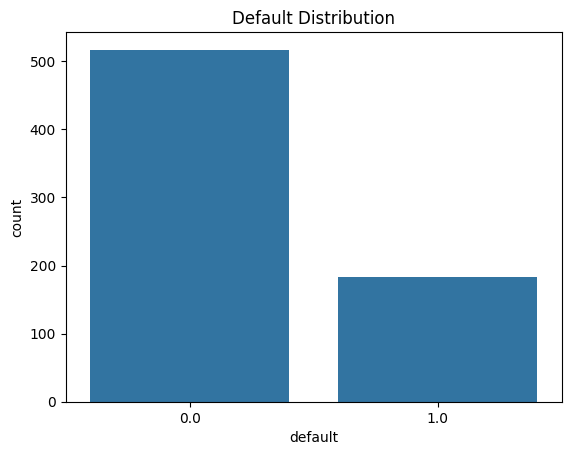

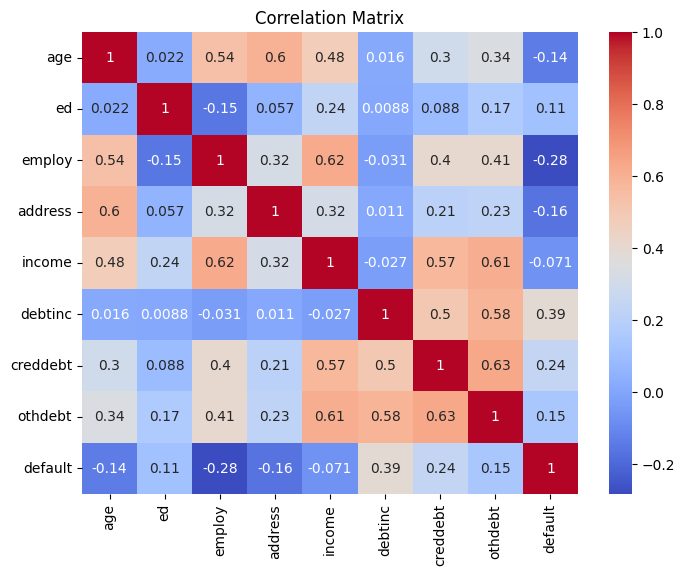

In [10]:
# Task 1
# Summary statistics
print('Summary Statistics:\n', data.describe())

# Distribution of target variable
sns.countplot(x='default', data=data)
plt.title("Default Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [11]:
# Task 2
# feature engineering
data['Total_Debt'] = data['creddebt'] + data['othdebt']

In [12]:
# Feature Scaling
X = data.drop('default', axis=1)
y = data['default']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
# Task 3
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
# Task 3
# Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [16]:
# Task 3
# Model Evaluation
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8285714285714286
Confusion Matrix:
 [[94  9]
 [15 22]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.91      0.89       103
         1.0       0.71      0.59      0.65        37

    accuracy                           0.83       140
   macro avg       0.79      0.75      0.77       140
weighted avg       0.82      0.83      0.82       140



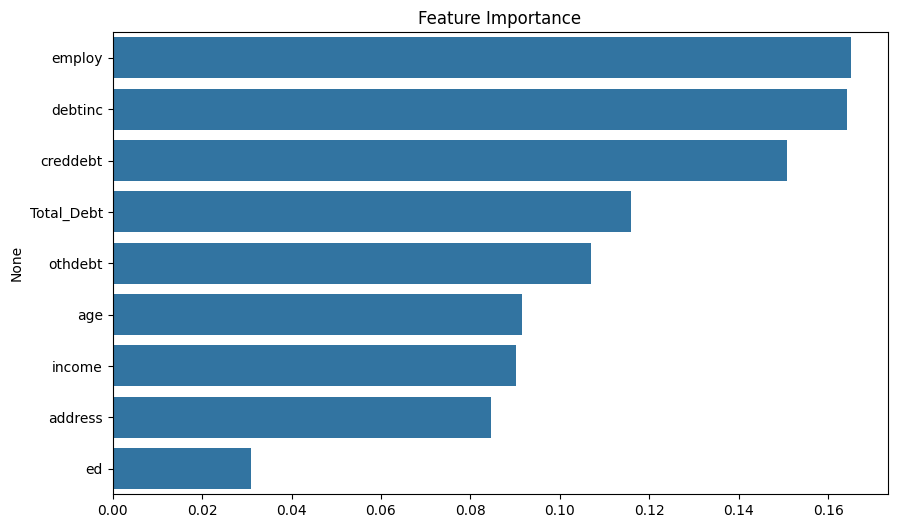

In [19]:
# Task 3
# Feature Importance
importances = model.feature_importances_
features = X.columns

# Sort features by importance (descending order)
indices = np.argsort(importances)[::-1]
importances = importances[indices]
features = features[indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.show()


Fairness Metrics By Age Group:

       selection_rate  false_positive_rate  true_positive_rate
age                                                           
20-30        0.272727             0.142857            0.500000
30-40        0.174603             0.060000            0.615385
40-60        0.242424             0.080000            0.750000


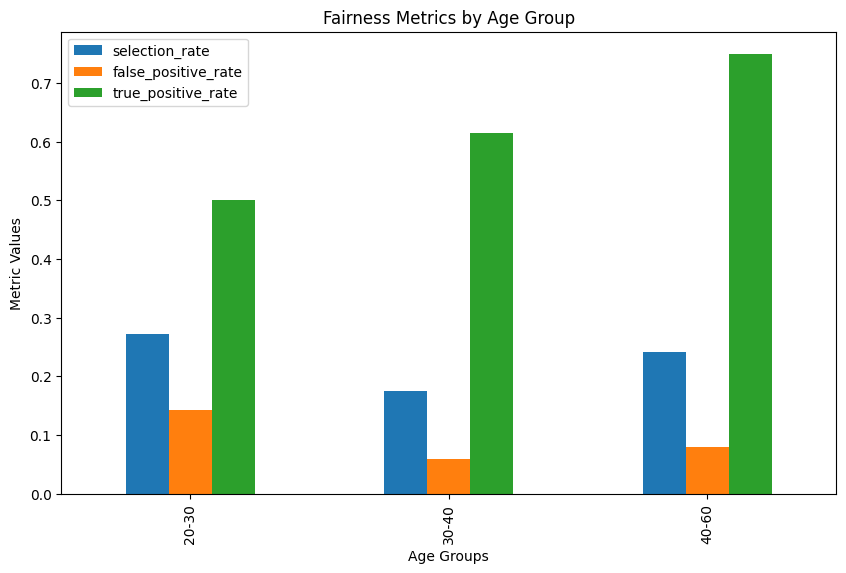

In [29]:
# Task 4
# Fairness Metrics

# Create sensitive feature
sensitive_feature = pd.cut( data['age'], bins=[20, 30, 40, 60, 100], labels=['20-30', '30-40', '40-60', '60+'])

# Create MetricFrame to compute fairness metrics by group
metric_frame = MetricFrame(
    metrics={
        'selection_rate': selection_rate,
        'false_positive_rate': false_positive_rate,
        'true_positive_rate': true_positive_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature[y_test.index]
)

# Display fairness results by group
print('\nFairness Metrics By Age Group:\n')
print(metric_frame.by_group)

# Visualization
metric_frame.by_group.plot(kind='bar', figsize=(10, 6))

plt.title("Fairness Metrics by Age Group")
plt.ylabel("Metric Values")
plt.xlabel("Age Groups")
plt.show()


SHAP summary plot for default (Class 1):



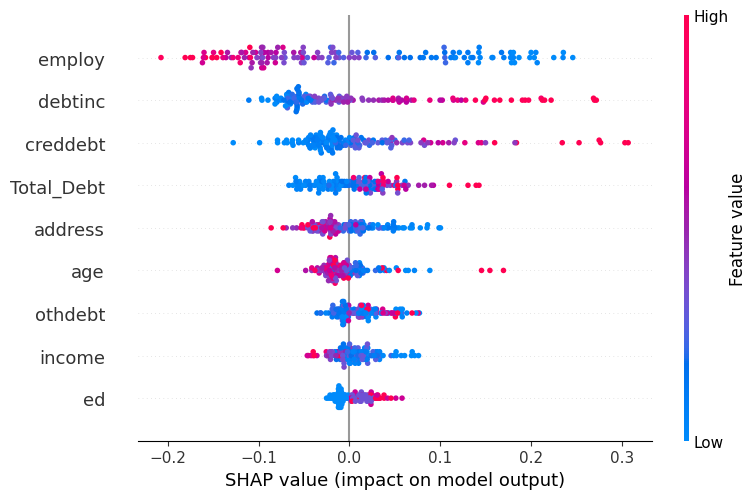

SHAP summary plot for no default (Class 0):


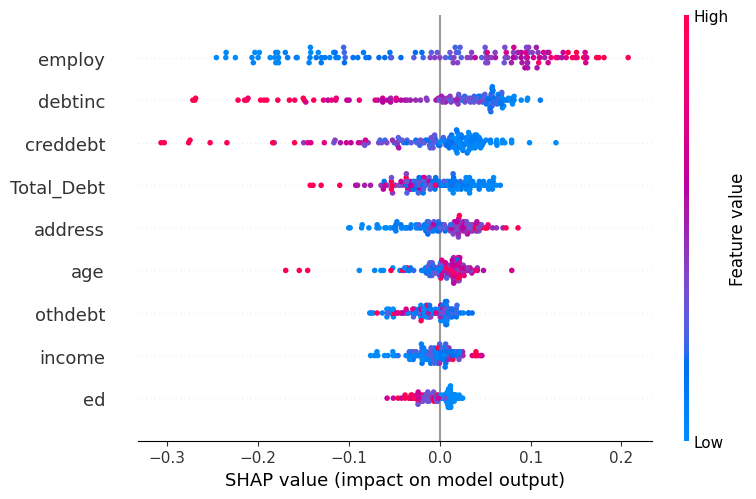

In [32]:
# Task 4
# SHAP explainability

## Create SHAP explainer for tree-based model
explainer = shap.TreeExplainer(model)

## Convert X_test (numpy array) back to DataFrame for SHAP plotting and calculation
# We need to ensure the columns match the original X DataFrame
X_test_df = pd.DataFrame(X_test, columns=X.columns)

## Compute SHAP values using the DataFrame
shap_values = explainer.shap_values(X_test_df)

print('\nSHAP summary plot for default (Class 1):\n')
shap.summary_plot(shap_values[:, :, 1], X_test_df)

print('SHAP summary plot for no default (Class 0):')
shap.summary_plot(shap_values[:, :, 0], X_test_df)

In [34]:
!touch Assignment15.ipynb
!git add Assignment15.ipynb
!git commit -m "Add Assignment 15"

[main e22ecb7] Add Assignment 15
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 Assignment15.ipynb
